# Simulador de Política Monetária Brasileira — modelo reduzido com calibração empírica

**Objetivo.** Construir, calibrar com dados reais e simular um modelo macroeconômico de forma reduzida (3 equações: Taylor + Phillips + IS) acoplado à aritmética da dívida pública, para estudar quantitativamente o argumento de **André Lara Resende (ALR)** sobre a (in)eficácia da política monetária no Brasil.

**Estrutura do notebook.**

1. Camada de dados — clientes para BACEN/SGS, Focus, SIDRA/IBGE, Tesouro
2. Construção da base trimestral consolidada
3. Estimação econométrica (OLS) dos parâmetros estruturais
4. Modelo reduzido — equações em forma de funções puras
5. Calibração de cenários (ortodoxo vs ALR)
6. Simulação de projeções e teste de robustez
7. Aritmética da dívida pública acoplada às projeções

**Equações do modelo.**

- **Curva IS** (demanda agregada):
$$\hat{y}_t = \rho_y \hat{y}_{t-1} - \sigma (i_{t-1} - \mathbb{E}_{t-1}\pi_t - r^*) + \varepsilon^{IS}_t$$

- **Curva de Phillips Novo-Keynesiana híbrida**:
$$\pi_t = \beta_b \pi_{t-1} + \beta_f \mathbb{E}_t\pi_{t+1} + \kappa \hat{y}_t + \gamma \Delta e_t + \varepsilon^\pi_t$$

- **Regra de Taylor**:
$$i_t = \rho_i i_{t-1} + (1-\rho_i)\left[r^* + \pi^* + \phi_\pi(\pi_t - \pi^*) + \phi_y \hat{y}_t\right] + \varepsilon^i_t$$

- **Dinâmica da dívida**:
$$b_{t+1} = \frac{1+i_t}{(1+\pi_t)(1+g_t)} b_t - p_t$$

A tese do **ALR** corresponde empiricamente a $\kappa \approx 0$ — política monetária não transmite via hiato do produto para inflação.


## 0. Setup e dependências

In [1]:
# Instale uma vez se necessário:
# !pip install requests pandas numpy statsmodels matplotlib seaborn

import os
import json
import time
import warnings
from pathlib import Path
from datetime import datetime, timedelta

import numpy as np
import pandas as pd
import requests
import statsmodels.api as sm
import statsmodels.formula.api as smf
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.titlesize"] = 12

# Diretório de cache local — evita rebaixar os dados a cada execução
CACHE_DIR = Path("./cache_dados")
CACHE_DIR.mkdir(exist_ok=True)

print("Setup OK. Cache em:", CACHE_DIR.absolute())

Setup OK. Cache em: C:\Users\Lenovo\Desktop\Desktop\Mestrado FGV\PoliticaMonetariaALR\files\cache_dados


## 1. Camada de dados

Quatro fontes online, cada uma com sua API:

| Fonte | Domínio | Cobertura |
|---|---|---|
| BACEN/SGS | `api.bcb.gov.br` | Selic, IPCA, dívida, câmbio, resultado fiscal, IBC-Br |
| BACEN/Olinda (Focus) | `olinda.bcb.gov.br` | Expectativas de mercado |
| IBGE/SIDRA | `apisidra.ibge.gov.br` | PIB trimestral, contas nacionais |
| Tesouro Transparente | `www.tesourotransparente.gov.br` | Composição da DPF |

Todas têm cache local em CSV para reprodutibilidade.

### 1.1 Cliente BACEN/SGS

In [2]:
import io

def _parse_sgs_json(text: str) -> pd.DataFrame:
    """Tenta parsear JSON do SGS, retornando None se não der."""
    if not text or not text.strip():
        return None
    s = text.lstrip()
    if s.startswith("<"):
        return None
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        return None
    if not isinstance(data, list) or len(data) == 0:
        return None
    return pd.DataFrame(data)


def _parse_sgs_csv(text: str) -> pd.DataFrame:
    if not text or not text.strip() or text.lstrip().startswith("<"):
        return None
    try:
        df = pd.read_csv(io.StringIO(text), sep=";", decimal=",")
        if df.empty:
            return None
        return df
    except Exception:
        return None


def _baixar_janela_sgs(codigo: int, inicio_dt, fim_dt, tentativas: int = 3):
    """Baixa uma janela do SGS com retry, fallback JSON→CSV, e tratamento de erros HTTP."""
    headers = {"User-Agent": "Mozilla/5.0 (compatible; simulador-pm/1.0)"}
    base = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados"
    params_comum = {
        "dataInicial": inicio_dt.strftime("%d/%m/%Y"),
        "dataFinal":   fim_dt.strftime("%d/%m/%Y"),
    }

    last_error = None
    for tentativa in range(tentativas):
        try:
            r = requests.get(base, params={**params_comum, "formato": "json"},
                             headers=headers, timeout=60)
            if r.status_code == 404:
                # Série não existe — não adianta tentar de novo
                return pd.DataFrame(), "404 (série não encontrada)"
            if r.status_code == 200:
                df = _parse_sgs_json(r.text)
                if df is not None:
                    return df, None
                # 200 mas corpo vazio/HTML → tenta CSV
                r2 = requests.get(base, params={**params_comum, "formato": "csv"},
                                  headers=headers, timeout=60)
                if r2.status_code == 200:
                    df = _parse_sgs_csv(r2.text)
                    if df is not None:
                        df = df.rename(columns={df.columns[0]: "data",
                                                df.columns[-1]: "valor"})
                        return df, None
                last_error = "200 com corpo vazio"
            elif r.status_code in (429, 502, 503, 504):
                last_error = f"HTTP {r.status_code}"
                time.sleep(2 ** tentativa)
                continue
            else:
                last_error = f"HTTP {r.status_code}"
        except requests.exceptions.RequestException as e:
            last_error = str(e)
            time.sleep(2 ** tentativa)
            continue
        time.sleep(1)
    return pd.DataFrame(), last_error


def sgs_get(codigo: int, inicio: str = "2002-01-01", fim: str = None,
            use_cache: bool = True, janela_anos: int = 4, silent: bool = False):
    """
    Baixa série temporal do SGS do BACEN.

    Args:
        codigo: código da série
        inicio, fim: 'YYYY-MM-DD'
        use_cache: usa ./cache_dados/sgs_{codigo}.csv
        janela_anos: chunks (4 anos é seguro após mudança BACEN 03/2025)
        silent: se True, não imprime aviso de falha

    Returns:
        DataFrame com índice 'data' e coluna 'valor'.
        DataFrame vazio se nada veio.
    """
    fim = fim or datetime.today().strftime("%Y-%m-%d")
    cache_file = CACHE_DIR / f"sgs_{codigo}.csv"

    if use_cache and cache_file.exists():
        return pd.read_csv(cache_file, parse_dates=["data"], index_col="data")

    inicio_dt = pd.to_datetime(inicio)
    fim_dt    = pd.to_datetime(fim)
    chunks = []
    erros_chunks = []
    cur = inicio_dt
    while cur < fim_dt:
        nxt = min(cur + pd.DateOffset(years=janela_anos), fim_dt)
        df_chunk, err = _baixar_janela_sgs(codigo, cur, nxt)
        if not df_chunk.empty:
            chunks.append(df_chunk)
        elif err:
            erros_chunks.append(err)
            # Se for 404, abandona — não vai melhorar
            if "404" in err:
                if not silent:
                    print(f"  [série {codigo}] 404: não existe.")
                return pd.DataFrame(columns=["valor"])
        cur = nxt + pd.Timedelta(days=1)
        time.sleep(0.4)

    if not chunks:
        # Última cartada em duas frentes:
        # (a) Talvez a série comece depois de 'inicio'. Tenta janelas
        #     progressivamente mais recentes desde 2008, 2010, 2015, 2020.
        for ano_alt in [2008, 2010, 2015, 2020]:
            inicio_alt = pd.to_datetime(f"{ano_alt}-01-01")
            if inicio_alt >= fim_dt:
                continue
            cur = inicio_alt
            while cur < fim_dt:
                nxt = min(cur + pd.DateOffset(years=janela_anos), fim_dt)
                df_chunk, _ = _baixar_janela_sgs(codigo, cur, nxt)
                if not df_chunk.empty:
                    chunks.append(df_chunk)
                cur = nxt + pd.Timedelta(days=1)
                time.sleep(0.4)
            if chunks:
                break
        # (b) Se ainda vazio, tenta o endpoint /ultimos/N
        if not chunks:
            try:
                headers = {"User-Agent": "Mozilla/5.0 (compatible; simulador-pm/1.0)"}
                url_ultimos = (f"https://api.bcb.gov.br/dados/serie/bcdata.sgs."
                               f"{codigo}/dados/ultimos/10000?formato=json")
                r = requests.get(url_ultimos, headers=headers, timeout=60)
                if r.status_code == 200:
                    df_alt = _parse_sgs_json(r.text)
                    if df_alt is not None:
                        chunks.append(df_alt)
            except Exception:
                pass

    if not chunks:
        if not silent:
            print(f"  [série {codigo}] vazia. Erros: {set(erros_chunks)}")
        return pd.DataFrame(columns=["valor"])

    df = pd.concat(chunks, ignore_index=True)
    df["data"] = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")
    df["valor"] = pd.to_numeric(df["valor"].astype(str).str.replace(",", "."),
                                errors="coerce")
    df = (df.dropna(subset=["data", "valor"])
            .drop_duplicates("data")
            .set_index("data")
            .sort_index()[["valor"]])

    if use_cache and not df.empty:
        df.to_csv(cache_file)
    return df


# Catálogo das séries com fallbacks
# (codigo_primario, descricao, codigo_fallback ou None, opcional?)
CATALOGO_SGS = {
    "selic_meta":       (432,   "Selic meta (% a.a.)",                4189,  False),
    "selic_efetiva":    (4189,  "Selic over (% a.a., anualizada)",    None,  False),
    "ipca_mensal":      (433,   "IPCA variação mensal (%)",           None,  False),
    "ipca_livres":      (11428, "IPCA livres mensal (%)",             None,  False),
    "ipca_monitorados": (4449,  "IPCA monitorados mensal (%)",        None,  False),
    "ipca_servicos":    (10844, "IPCA serviços mensal (%)",           None,  True),   # opcional
    "igp_m":            (189,   "IGP-M mensal (%)",                   None,  False),
    "ptax_venda":       (1,     "PTAX venda (R$/US$)",                None,  False),
    "ibc_br":           (24364, "IBC-Br dessazonalizado",             None,  False),
    "dbgg_pct_pib":     (13762, "Dívida Bruta Gov. Geral (% PIB)",    None,  False),
    "dlsp_pct_pib":     (4513,  "Dívida Líquida Setor Público (% PIB)", None, False),
    "primario_12m":     (5793,  "Resultado primário 12m (% PIB)",     None,  False),
    "juros_nom_12m":    (5760,  "Juros nominais 12m (% PIB)",         None,  False),  # era 5794
    "nominal_12m":      (5727,  "Resultado nominal 12m (% PIB)",      None,  False),  # era 5795
    "credito_pib":      (20622, "Crédito total / PIB (%)",            None,  True),
}

print(f"Catálogo SGS: {len(CATALOGO_SGS)} séries")
for k, (cod, desc, fb, opcional) in CATALOGO_SGS.items():
    flag = " [opcional]" if opcional else ""
    fb_txt = f" → fallback {fb}" if fb else ""
    print(f"  {k:20s} ({cod:>6}){flag}: {desc}{fb_txt}")

Catálogo SGS: 15 séries
  selic_meta           (   432): Selic meta (% a.a.) → fallback 4189
  selic_efetiva        (  4189): Selic over (% a.a., anualizada)
  ipca_mensal          (   433): IPCA variação mensal (%)
  ipca_livres          ( 11428): IPCA livres mensal (%)
  ipca_monitorados     (  4449): IPCA monitorados mensal (%)
  ipca_servicos        ( 10844) [opcional]: IPCA serviços mensal (%)
  igp_m                (   189): IGP-M mensal (%)
  ptax_venda           (     1): PTAX venda (R$/US$)
  ibc_br               ( 24364): IBC-Br dessazonalizado
  dbgg_pct_pib         ( 13762): Dívida Bruta Gov. Geral (% PIB)
  dlsp_pct_pib         (  4513): Dívida Líquida Setor Público (% PIB)
  primario_12m         (  5793): Resultado primário 12m (% PIB)
  juros_nom_12m        (  5760): Juros nominais 12m (% PIB)
  nominal_12m          (  5727): Resultado nominal 12m (% PIB)
  credito_pib          ( 20622) [opcional]: Crédito total / PIB (%)


In [3]:
# Função auxiliar com TODAS as estratégias de download
def baixar_com_fallback(codigo: int, fallback_codigo=None):
    """
    Tenta baixar uma série usando várias estratégias.
    Retorna o primeiro DataFrame não vazio.
    """
    estrategias = [
        # (descricao curta, inicio, janela_anos)
        ("janela 4 anos desde 2002",     "2002-01-01", 4),
        ("janela 2 anos desde 2006",     "2006-12-01", 2),
        ("janela 4 anos desde 2010",     "2010-01-01", 4),
        ("janela 2 anos desde 2015",     "2015-01-01", 2),
        ("janela 1 ano desde 2020",      "2020-01-01", 1),
    ]
    for desc, inicio, janela in estrategias:
        df = sgs_get(codigo, inicio=inicio, janela_anos=janela, 
                     use_cache=False, silent=True)
        if not df.empty:
            return df, f"{codigo} via {desc}"

    # Endpoint /ultimos/N (não exige janela)
    try:
        headers = {"User-Agent": "Mozilla/5.0 (compatible; simulador-pm/1.0)"}
        url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados/ultimos/10000?formato=json"
        r = requests.get(url, headers=headers, timeout=60)
        if r.status_code == 200 and r.text.strip() and not r.text.lstrip().startswith("<"):
            raw = json.loads(r.text)
            if raw:
                df = pd.DataFrame(raw)
                df["data"]  = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")
                df["valor"] = pd.to_numeric(df["valor"].astype(str).str.replace(",", "."),
                                            errors="coerce")
                df = (df.dropna(subset=["data", "valor"])
                        .drop_duplicates("data")
                        .set_index("data")
                        .sort_index()[["valor"]])
                if not df.empty:
                    return df, f"{codigo} via /ultimos/10000"
    except Exception:
        pass

    # Tenta o código fallback se houver
    if fallback_codigo is not None:
        return baixar_com_fallback(fallback_codigo)

    return pd.DataFrame(), None


# Loop principal — agora com fallback agressivo
dados_sgs = {}
falhas_criticas = []
falhas_opcionais = []

for nome, (codigo, desc, fallback, opcional) in CATALOGO_SGS.items():
    # Primeiro: cache
    cache_file = CACHE_DIR / f"sgs_{codigo}.csv"
    if cache_file.exists():
        df = pd.read_csv(cache_file, parse_dates=["data"], index_col="data")
        if not df.empty:
            dados_sgs[nome] = df
            print(f"  {nome:20s}: {len(df):>5} obs (cache), "
                  f"{df.index.min().date()} → {df.index.max().date()}")
            continue

    # Segundo: baixar com todas as estratégias
    df, origem = baixar_com_fallback(codigo, fallback)
    
    if not df.empty:
        dados_sgs[nome] = df
        df.to_csv(cache_file)  # grava cache para próxima vez
        print(f"  {nome:20s}: {len(df):>5} obs [{origem}], "
              f"{df.index.min().date()} → {df.index.max().date()}")
    else:
        if opcional:
            falhas_opcionais.append(nome)
            print(f"  {nome:20s}: TODAS as estratégias falharam [OPCIONAL — segue]")
        else:
            falhas_criticas.append(nome)
            print(f"  {nome:20s}: TODAS as estratégias falharam [CRÍTICA]")

print(f"\n{len(dados_sgs)} séries OK, "
      f"{len(falhas_criticas)} críticas falharam, "
      f"{len(falhas_opcionais)} opcionais falharam")
print(f"CACHE_DIR: {CACHE_DIR.absolute()}")

if falhas_criticas:
    print(f"\n⚠ Séries críticas faltando: {falhas_criticas}")
    print("Workaround: usar DLSP como proxy de DBGG (mesma dinâmica para o argumento ALR):")
    print('  dados_sgs["dbgg_pct_pib"] = dados_sgs["dlsp_pct_pib"]')

  selic_meta          :  8905 obs (cache), 2002-01-01 → 2026-05-19
  selic_efetiva       :   293 obs (cache), 2002-01-01 → 2026-05-01
  ipca_mensal         :   292 obs (cache), 2002-01-01 → 2026-04-01
  ipca_livres         :   292 obs (cache), 2002-01-01 → 2026-04-01
  ipca_monitorados    :   292 obs (cache), 2002-01-01 → 2026-04-01
  ipca_servicos       :   292 obs (cache), 2002-01-01 → 2026-04-01
  igp_m               :   292 obs (cache), 2002-01-01 → 2026-04-01
  ptax_venda          :  6124 obs (cache), 2002-01-02 → 2026-05-19
  ibc_br              :   279 obs (cache), 2003-01-01 → 2026-03-01
  dbgg_pct_pib        :   232 obs (cache), 2006-12-01 → 2026-03-01
  dlsp_pct_pib        :   291 obs (cache), 2002-01-01 → 2026-03-01
  primario_12m        :   281 obs (cache), 2002-11-01 → 2026-03-01
  juros_nom_12m       :   281 obs (cache), 2002-11-01 → 2026-03-01
  nominal_12m         :   281 obs (cache), 2002-11-01 → 2026-03-01
  credito_pib         :   291 obs (cache), 2002-01-01 → 2026-0

### 1.1.1 Diagnóstico manual (opcional)

A célula acima já recupera séries automaticamente. Se precisar investigar uma série específica em detalhe, descomente a chamada `diagnosticar_sgs(codigo)` abaixo.

In [4]:
# =======================================================================
# Recuperação robusta de séries que falharam.
#
# Esta célula faz, em ordem:
# 1. Verifica se DBGG (13762) está em `dados_sgs`. Se sim, OK.
# 2. Se não, tenta carregar do cache em disco.
# 3. Se também não tem cache, baixa do BACEN com estratégias múltiplas.
# 4. Grava no cache no diretório correto para próximas execuções.
# =======================================================================

def recuperar_serie(nome: str, codigo: int, inicio_serie: str = "2002-01-01"):
    """Tenta de várias formas até obter a série. Atualiza dados_sgs e grava cache."""
    if nome in dados_sgs and not dados_sgs[nome].empty:
        print(f"  ✓ {nome}: já em dados_sgs ({len(dados_sgs[nome])} obs)")
        return dados_sgs[nome]

    # 1. Tenta ler cache
    cache_path = CACHE_DIR / f"sgs_{codigo}.csv"
    if cache_path.exists():
        try:
            df = pd.read_csv(cache_path, parse_dates=["data"], index_col="data")
            if not df.empty:
                dados_sgs[nome] = df
                print(f"  ✓ {nome}: recuperada do cache ({len(df)} obs)")
                return df
        except Exception as e:
            print(f"  ! cache existe mas falhou ao ler: {e}")

    # 2. Baixa do BACEN — várias estratégias em sequência
    estrategias = [
        # (descricao, kwargs para sgs_get)
        ("janela 2 anos a partir de início da série",
         {"inicio": inicio_serie, "janela_anos": 2}),
        ("janela 1 ano a partir de 2006",
         {"inicio": "2006-12-01", "janela_anos": 1}),
        ("janela 4 anos desde 2010",
         {"inicio": "2010-01-01", "janela_anos": 4}),
        ("/ultimos/N",
         None),  # tratamento especial
    ]

    for desc, kwargs in estrategias:
        print(f"    tentando: {desc}...")
        try:
            if kwargs is not None:
                df = sgs_get(codigo, use_cache=False, silent=True, **kwargs)
            else:
                # Endpoint /ultimos/N
                headers = {"User-Agent": "Mozilla/5.0 (compatible; simulador-pm/1.0)"}
                url = f"https://api.bcb.gov.br/dados/serie/bcdata.sgs.{codigo}/dados/ultimos/10000?formato=json"
                r = requests.get(url, headers=headers, timeout=60)
                if r.status_code != 200:
                    print(f"      HTTP {r.status_code}")
                    continue
                raw = r.json()
                if not raw:
                    continue
                df = pd.DataFrame(raw)
                df["data"]  = pd.to_datetime(df["data"], format="%d/%m/%Y", errors="coerce")
                df["valor"] = pd.to_numeric(df["valor"].astype(str).str.replace(",", "."),
                                             errors="coerce")
                df = (df.dropna(subset=["data", "valor"])
                        .drop_duplicates("data")
                        .set_index("data")
                        .sort_index()[["valor"]])
        except Exception as e:
            print(f"      exceção: {e}")
            continue

        if not df.empty:
            df.to_csv(cache_path)
            dados_sgs[nome] = df
            print(f"  ✓ {nome}: {len(df)} obs ({df.index.min().date()} → {df.index.max().date()})")
            print(f"    cache salvo em: {cache_path.absolute()}")
            return df

    print(f"  ✗ {nome}: TODAS as estratégias falharam.")
    return pd.DataFrame()


# Lista de séries que podem ter falhado
serie_recuperar = [
    ("dbgg_pct_pib", 13762, "2006-12-01"),
]

print(f"CACHE_DIR está em: {CACHE_DIR.absolute()}\n")
print("Recuperando séries faltantes:\n")

for nome, codigo, inicio in serie_recuperar:
    recuperar_serie(nome, codigo, inicio)
    print()

# Sanity check final
print("Resumo final de dados_sgs:")
for nome in sorted(dados_sgs):
    df = dados_sgs[nome]
    if not df.empty:
        print(f"  {nome:20s}: {len(df):>5} obs, "
              f"{df.index.min().date()} → {df.index.max().date()}")

# Garante que DBGG está disponível antes de prosseguir
if "dbgg_pct_pib" not in dados_sgs or dados_sgs["dbgg_pct_pib"].empty:
    print("\n⚠ DBGG ainda não disponível. Você pode prosseguir usando DLSP como proxy:")
    print('   dados_sgs["dbgg_pct_pib"] = dados_sgs["dlsp_pct_pib"]')
    print("   (DLSP tem nível menor mas mesma dinâmica para o argumento do ALR)")

CACHE_DIR está em: C:\Users\Lenovo\Desktop\Desktop\Mestrado FGV\PoliticaMonetariaALR\files\cache_dados

Recuperando séries faltantes:

  ✓ dbgg_pct_pib: já em dados_sgs (232 obs)

Resumo final de dados_sgs:
  credito_pib         :   291 obs, 2002-01-01 → 2026-03-01
  dbgg_pct_pib        :   232 obs, 2006-12-01 → 2026-03-01
  dlsp_pct_pib        :   291 obs, 2002-01-01 → 2026-03-01
  ibc_br              :   279 obs, 2003-01-01 → 2026-03-01
  igp_m               :   292 obs, 2002-01-01 → 2026-04-01
  ipca_livres         :   292 obs, 2002-01-01 → 2026-04-01
  ipca_mensal         :   292 obs, 2002-01-01 → 2026-04-01
  ipca_monitorados    :   292 obs, 2002-01-01 → 2026-04-01
  ipca_servicos       :   292 obs, 2002-01-01 → 2026-04-01
  juros_nom_12m       :   281 obs, 2002-11-01 → 2026-03-01
  nominal_12m         :   281 obs, 2002-11-01 → 2026-03-01
  primario_12m        :   281 obs, 2002-11-01 → 2026-03-01
  ptax_venda          :  6124 obs, 2002-01-02 → 2026-05-19
  selic_efetiva       :   

### 1.2 Cliente Focus (Olinda OData)

In [5]:
from urllib.parse import quote

def focus_get(indicador: str, data_ref_min: int = 2010,
              tipo: str = "anuais", use_cache: bool = True,
              base_calculo: int = 0, suavizada: str = "S") -> pd.DataFrame:
    """
    Baixa expectativas Focus do BACEN via Olinda OData.

    Importante: o BACEN tem bug no parser OData quando `requests` faz
    url-encoding dos filtros. Construímos a URL manualmente, codificando
    apenas o valor (Câmbio → C%C3%A2mbio), preservando os caracteres
    estruturais da URL (=, &, $, ', espaços etc.).
    """
    nome_cache = f"focus_{tipo}_{indicador.replace(' ', '_').replace('ç','c').replace('â','a')}"
    cache_file = CACHE_DIR / f"{nome_cache}.csv"
    if use_cache and cache_file.exists():
        df = pd.read_csv(cache_file, parse_dates=["Data"])
        return df

    endpoint = {
        "anuais":      "ExpectativasMercadoAnuais",
        "mensais":     "ExpectativaMercadoMensais",
        "trimestrais": "ExpectativasMercadoTrimestrais",
        "inflacao12m": "ExpectativasMercadoInflacao12Meses",
        "inflacao24m": "ExpectativasMercadoInflacao24Meses",
        "selic":       "ExpectativasMercadoSelic",
    }[tipo]

    base_url = f"https://olinda.bcb.gov.br/olinda/servico/Expectativas/versao/v1/odata/{endpoint}"
    headers = {"User-Agent": "Mozilla/5.0 (compatible; simulador-pm/1.0)"}

    # Codifica APENAS o valor do indicador (preserva aspas e operadores)
    indicador_url = quote(indicador, safe="")

    todas_linhas = []
    skip = 0
    chunk_size = 10000

    while True:
        # URL construída manualmente — sem requests fazer params={}
        filtro = f"Indicador%20eq%20'{indicador_url}'"
        url = (f"{base_url}"
               f"?$top={chunk_size}"
               f"&$skip={skip}"
               f"&$filter={filtro}"
               f"&$format=json")

        r = requests.get(url, headers=headers, timeout=120)

        if r.status_code != 200:
            print(f"  [{indicador}/{tipo}] HTTP {r.status_code}: {r.text[:300]}")
            break

        try:
            data = r.json().get("value", [])
        except Exception as e:
            print(f"  [{indicador}/{tipo}] JSON inválido: {e}")
            break

        if not data:
            break
        todas_linhas.extend(data)
        if len(data) < chunk_size:
            break
        skip += chunk_size
        time.sleep(0.5)

    if not todas_linhas:
        print(f"  [{indicador}/{tipo}] nenhuma observação retornada.")
        return pd.DataFrame()

    df = pd.DataFrame(todas_linhas)
    df["Data"] = pd.to_datetime(df["Data"])

    # Filtragem local (mais robusta que OData do BACEN)
    if "baseCalculo" in df.columns:
        df = df[df["baseCalculo"] == base_calculo].copy()
    if "Suavizada" in df.columns:
        df = df[df["Suavizada"] == suavizada].copy()
    if "DataReferencia" in df.columns and tipo in ("anuais", "mensais", "trimestrais"):
        df["AnoRef"] = df["DataReferencia"].astype(str).str[:4]
        try:
            df = df[df["AnoRef"].astype(int) >= data_ref_min].copy()
        except Exception:
            pass

    df = df.sort_values("Data").reset_index(drop=True)
    if use_cache and not df.empty:
        df.to_csv(cache_file, index=False)
    return df


# Baixa expectativas para IPCA, PIB, Selic e Câmbio (anuais)
print("Baixando expectativas Focus anuais (URL manual)...")
focus_ipca   = focus_get("IPCA")
print(f"  IPCA anuais:   {len(focus_ipca)} obs")
focus_pib    = focus_get("PIB Total")
print(f"  PIB anuais:    {len(focus_pib)} obs")
focus_selic  = focus_get("Selic")
print(f"  Selic anuais:  {len(focus_selic)} obs")
focus_cambio = focus_get("Câmbio")
print(f"  Câmbio anuais: {len(focus_cambio)} obs")

Baixando expectativas Focus anuais (URL manual)...
  IPCA anuais:   23026 obs
  PIB anuais:    22843 obs
  Selic anuais:  23133 obs
  Câmbio anuais: 23054 obs


### 1.3 Cliente IBGE/SIDRA — PIB trimestral encadeado

In [6]:
def sidra_get(query: str, use_cache: bool = True, nome_cache: str = None) -> pd.DataFrame:
    """
    Baixa tabela SIDRA. A 'query' é o path estilo SIDRA: /t/<tab>/n/<niv>/v/<var>/p/<per>/...
    Exemplo PIB trimestral encadeado (tabela 1620, var 583):
        /t/1620/n1/all/v/583/p/all/c11255/90707/d/v583%201
    """
    nome_cache = nome_cache or query.replace("/", "_").strip("_")
    cache_file = CACHE_DIR / f"sidra_{nome_cache}.csv"
    if use_cache and cache_file.exists():
        return pd.read_csv(cache_file)

    url = f"https://apisidra.ibge.gov.br/values{query}"
    r = requests.get(url, timeout=120)
    r.raise_for_status()
    data = r.json()
    # primeira linha é cabeçalho descritivo, segunda em diante são dados
    if not data or len(data) < 2:
        return pd.DataFrame()
    header = data[0]
    rows = data[1:]
    df = pd.DataFrame(rows)
    # renomeia para nomes legíveis usando o header como mapa
    df = df.rename(columns=header)
    if use_cache:
        df.to_csv(cache_file, index=False)
    return df

# PIB trimestral, índice encadeado dessazonalizado (1995=100), tabela 1620 variável 583
# c11255/90707 = Total
pib_tri = sidra_get(
    "/t/1620/n1/all/v/583/p/all/c11255/90707",
    nome_cache="pib_tri_encadeado"
)

print("PIB trimestral:", len(pib_tri), "linhas")
print(pib_tri.head(3))

PIB trimestral: 120 linhas
   Nível Territorial (Código) Nível Territorial  Unidade de Medida (Código)  \
0                           1            Brasil                          30   
1                           1            Brasil                          30   
2                           1            Brasil                          30   

  Unidade de Medida   Valor  Brasil (Código)  Brasil  Variável (Código)  \
0     Número-índice   96.84                1  Brasil                583   
1     Número-índice  100.12                1  Brasil                583   
2     Número-índice  107.56                1  Brasil                583   

                                            Variável  Trimestre (Código)  \
0  Série encadeada do índice de volume trimestral...              199601   
1  Série encadeada do índice de volume trimestral...              199602   
2  Série encadeada do índice de volume trimestral...              199603   

           Trimestre  Setores e subsetores (Código

### 1.4 Cliente Tesouro Transparente — composição da DPF

In [7]:
def tesouro_dpf_estoque(use_cache: bool = True) -> pd.DataFrame:
    """
    Baixa estoque da Dívida Pública Federal por indexador (LFT/LTN/NTN-B/etc).
    """
    cache_file = CACHE_DIR / "tesouro_dpf_estoque.csv"
    if use_cache and cache_file.exists():
        try:
            return pd.read_csv(cache_file)
        except Exception:
            pass

    headers = {"User-Agent": "Mozilla/5.0 (compatible; simulador-pm/1.0)"}
    url = "https://www.tesourotransparente.gov.br/ckan/api/3/action/package_show?id=estoque-da-divida-publica-federal"
    r = requests.get(url, headers=headers, timeout=60)
    r.raise_for_status()
    pkg = r.json()
    resources = pkg["result"]["resources"]
    csv_resource = next((r for r in resources if r["format"].upper() == "CSV"), None)
    if csv_resource is None:
        raise RuntimeError("Recurso CSV não encontrado no pacote DPF")
    # Tenta múltiplos encodings e separadores
    for enc in ("latin1", "utf-8"):
        for sep in (";", ","):
            try:
                df = pd.read_csv(csv_resource["url"], sep=sep, decimal=",", encoding=enc)
                if df.shape[1] > 3:
                    break
            except Exception:
                continue
        else:
            continue
        break
    else:
        raise RuntimeError("Não conseguiu ler o CSV do Tesouro")
    if use_cache:
        df.to_csv(cache_file, index=False)
    return df

try:
    dpf = tesouro_dpf_estoque()
    print(f"DPF — shape: {dpf.shape}")
    print(f"Colunas: {dpf.columns.tolist()[:8]}")
except Exception as e:
    print(f"Aviso: Tesouro Transparente falhou ({e}). "
          "Composição da dívida será omitida.")
    dpf = pd.DataFrame()

DPF — shape: (162047, 7)
Colunas: ['Titulo/Contrato', 'Vencimento do Titulo/Contrato', 'Valor do Estoque', 'Quantidade do Estoque', 'Mes do Estoque', 'Classe da Carteira', 'Tipo de Divida']


## 2. Construção da base trimestral consolidada

O modelo trabalha em **frequência trimestral**. Vamos:

1. Agregar IPCA mensal em IPCA acumulado trimestral
2. Anualizar Selic
3. Calcular o **hiato do produto** ($\hat{y}_t$) via filtro Hodrick-Prescott no PIB
4. Calcular a **variação cambial trimestral**
5. Reunir tudo numa única tabela com índice trimestral

O hiato do produto é a peça mais delicada. Aqui usamos HP com $\lambda = 1600$ (padrão para dados trimestrais).

In [8]:
def para_trimestral_inflacao(serie_mensal: pd.DataFrame) -> pd.Series:
    """Acumula inflação mensal em trimestral via (1+π_m1)(1+π_m2)(1+π_m3) − 1."""
    s = serie_mensal["valor"] / 100
    fator = (1 + s).resample("QE").prod() - 1
    return fator * 100  # de volta para %

def para_trimestral_media(serie: pd.DataFrame) -> pd.Series:
    return serie["valor"].resample("QE").mean()

def para_trimestral_ultimo(serie: pd.DataFrame) -> pd.Series:
    return serie["valor"].resample("QE").last()

# IPCA trimestral (acumulado nos 3 meses do trimestre)
ipca_tri = para_trimestral_inflacao(dados_sgs["ipca_mensal"])

# IPCA ACUMULADO EM 12 MESES (igual ao indicador oficial do IBGE).
# CORREÇÃO: a versão anterior anualizava um único trimestre via (1+tri)**4,
# o que amplifica o ruído mensal e diverge do dado oficial. Aqui usamos o
# acumulado real dos últimos 12 meses, alinhado ao fim de cada trimestre.
_ipca_mensal_frac = dados_sgs["ipca_mensal"]["valor"] / 100
ipca_12m_mensal = ((1 + _ipca_mensal_frac).rolling(12).apply(np.prod, raw=True) - 1) * 100
ipca_anual_12m = ipca_12m_mensal.resample("QE").last()

# Selic — média trimestral da meta (já anualizada na fonte)
selic_tri = para_trimestral_media(dados_sgs["selic_meta"])

# Câmbio — variação trimestral
cambio_fim = dados_sgs["ptax_venda"]["valor"].resample("QE").last()
delta_cambio = cambio_fim.pct_change() * 100

# Dívida e fiscal — último dia do trimestre
dbgg_tri      = para_trimestral_ultimo(dados_sgs["dbgg_pct_pib"])
primario_tri  = para_trimestral_ultimo(dados_sgs["primario_12m"])
juros_nom_tri = (para_trimestral_ultimo(dados_sgs["juros_nom_12m"])
                 if "juros_nom_12m" in dados_sgs else pd.Series(dtype=float))

# IBC-Br — proxy de atividade mensal → trimestral
ibc_tri = para_trimestral_media(dados_sgs["ibc_br"])

base = pd.DataFrame({
    "selic":         selic_tri,
    "ipca_tri":      ipca_tri,
    "ipca_anual":    ipca_anual_12m,  # IPCA acum. 12 meses (oficial IBGE)
    "delta_cambio":  delta_cambio,
    "ibc_br":        ibc_tri,
    "dbgg_pct_pib":  dbgg_tri,
    "primario_12m":  primario_tri,
    "juros_nom_12m": juros_nom_tri,
})
base.index = base.index.to_period("Q").to_timestamp(how="end").normalize()
base = base.dropna(how="all")
print("Base trimestral:", base.shape)
print(base.tail(8).round(2))

Base trimestral: (98, 8)
            selic  ipca_tri  ipca_anual  delta_cambio  ibc_br  dbgg_pct_pib  \
data                                                                          
2024-09-30  10.53      0.80        4.42         -1.99  107.33         77.09   
2024-12-31  11.27      1.48        4.83         13.66  107.69         76.27   
2025-03-31  13.06      2.04        5.48         -7.27  109.04         75.55   
2025-06-30  14.58      0.93        5.35         -4.96  109.47         76.30   
2025-09-30  15.00      0.63        5.17         -2.54  108.63         77.84   
2025-12-31  15.00      0.60        4.26          3.46  109.02         78.64   
2026-03-31  14.96      1.92        4.14         -5.14  110.42         80.04   
2026-06-30  14.65      0.67        4.39         -3.48     NaN           NaN   

            primario_12m  juros_nom_12m  
data                                     
2024-09-30          2.12           7.08  
2024-12-31          0.40           8.07  
2025-03-31      

### Validação do IPCA acumulado 12 meses

A célula abaixo confere que `ipca_anual` (acumulado em 12 meses) bate com o
indicador oficial do IBGE. Para abril/2026, o IPCA 12m oficial foi **4,39%**.
Se o valor no fim da série divergir muito disso, há problema na coleta dos dados.

In [9]:
# --- Validação do IPCA acumulado 12 meses ---
_chk = base["ipca_anual"].dropna()
print(f"IPCA acum. 12m — últimos 6 trimestres:")
print(_chk.tail(6).round(2).to_string())
print()
print(f"Último valor disponível: {_chk.iloc[-1]:.2f}%  (IBGE abr/2026: ~4,39%)")
print(f"Média da série:          {_chk.mean():.2f}%")
print(f"Min / Max:               {_chk.min():.2f}% / {_chk.max():.2f}%")

# Sanity check: a inflação anual deve estar entre -2% e 20% para o Brasil
assert -2 < _chk.iloc[-1] < 20, "IPCA fora da faixa plausível — revisar coleta!"
assert _chk.std() < 5, "Volatilidade do IPCA anormalmente alta — verificar se não está anualizando 1 trimestre!"
print("\n✓ Validação OK: IPCA dentro da faixa esperada e suave.")

IPCA acum. 12m — últimos 6 trimestres:
data
2025-03-31    5.48
2025-06-30    5.35
2025-09-30    5.17
2025-12-31    4.26
2026-03-31    4.14
2026-06-30    4.39
Freq: QE-DEC

Último valor disponível: 4.39%  (IBGE abr/2026: ~4,39%)
Média da série:          6.08%
Min / Max:               2.13% / 16.57%

✓ Validação OK: IPCA dentro da faixa esperada e suave.



Estatísticas do hiato (%):
count    93.00
mean     -0.00
std       2.11
min     -10.98
25%      -0.92
50%       0.34
75%       1.22
max       3.56
Name: hiato, dtype: float64


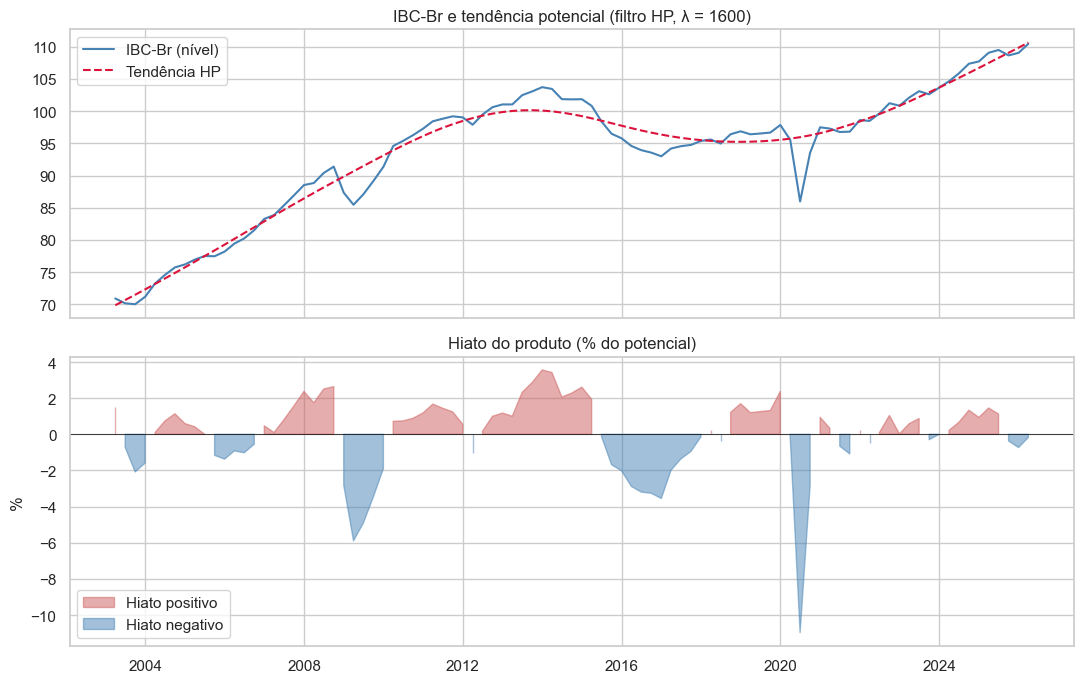

In [10]:
# Hiato do produto via filtro HP no IBC-Br (proxy de PIB mensal)
from statsmodels.tsa.filters.hp_filter import hpfilter

# IMPORTANTE: o filtro HP só roda no subset não-nulo do IBC-Br.
# O índice 'idx_hp' é menor que base.index (IBC-Br começa em 2003).
ibc_log = np.log(base["ibc_br"].dropna())
idx_hp = ibc_log.index
cycle, trend = hpfilter(ibc_log, lamb=1600)

# Atribui hiato e tendência usando o mesmo índice do filtro
base.loc[idx_hp, "hiato"]    = cycle * 100              # em %
base.loc[idx_hp, "trend_hp"] = np.exp(trend)            # nível da tendência

# Crescimento real do PIB anualizado a partir do IBC-Br (YoY)
base["g_real_yoy"] = base["ibc_br"].pct_change(4) * 100

print("\nEstatísticas do hiato (%):")
print(base["hiato"].describe().round(2))

fig, axes = plt.subplots(2, 1, figsize=(11, 7), sharex=True)

# Plot 1: nível e tendência — ambos no mesmo índice
axes[0].plot(idx_hp, base.loc[idx_hp, "ibc_br"],
             label="IBC-Br (nível)", color="steelblue")
axes[0].plot(idx_hp, base.loc[idx_hp, "trend_hp"],
             label="Tendência HP", color="crimson", linestyle="--")
axes[0].set_title("IBC-Br e tendência potencial (filtro HP, λ = 1600)")
axes[0].legend()

# Plot 2: hiato
hiato_plot = base["hiato"].dropna()
axes[1].fill_between(hiato_plot.index, hiato_plot, 0,
                     where=hiato_plot >= 0, color="indianred",
                     alpha=0.5, label="Hiato positivo")
axes[1].fill_between(hiato_plot.index, hiato_plot, 0,
                     where=hiato_plot < 0, color="steelblue",
                     alpha=0.5, label="Hiato negativo")
axes[1].axhline(0, color="black", linewidth=0.5)
axes[1].set_title("Hiato do produto (% do potencial)")
axes[1].set_ylabel("%")
axes[1].legend()

plt.tight_layout()
plt.show()

### 2.1 Expectativas Focus integradas

Pegamos a **expectativa de IPCA para 12 meses à frente** medida na data do trimestre, que será usada como $\mathbb{E}_t \pi_{t+1}$ na curva de Phillips.

In [11]:
# Mediana semanal de IPCA 12 meses → trimestral
focus_ipca_12m = focus_get("IPCA", tipo="inflacao12m")
if not focus_ipca_12m.empty:
    focus_ipca_12m = focus_ipca_12m.set_index("Data")
    exp_ipca_tri = focus_ipca_12m["Mediana"].resample("QE").last()
    base["exp_ipca_12m"] = exp_ipca_tri
    print(f"Expectativa IPCA 12m incorporada: {focus_ipca_12m.index.min().date()} → {focus_ipca_12m.index.max().date()}")
else:
    # Fallback: usa a expectativa para o ano corrente como proxy
    if not focus_ipca.empty:
        # Pega a mediana mais próxima da data, com DataReferencia = ano corrente
        exp_anual = focus_ipca.set_index("Data")["Mediana"]
        # Filtra por DataReferencia próxima (1 ano à frente)
        focus_ipca["AnoRef_int"] = focus_ipca["DataReferencia"].astype(str).str[:4].astype(int)
        focus_ipca["AnoData"] = focus_ipca["Data"].dt.year
        proximo = focus_ipca[focus_ipca["AnoRef_int"] == focus_ipca["AnoData"] + 1]
        if not proximo.empty:
            exp_ipca_tri = proximo.set_index("Data")["Mediana"].resample("QE").last()
            base["exp_ipca_12m"] = exp_ipca_tri
            print(f"Expectativa IPCA próximo ano (proxy): {len(exp_ipca_tri.dropna())} obs trimestrais")
        else:
            base["exp_ipca_12m"] = base["ipca_anual"].shift(-4)
            print("Aviso: Focus indisponível, usando IPCA realizado lead 4 como proxy.")
    else:
        base["exp_ipca_12m"] = base["ipca_anual"].shift(-4)
        print("Aviso: Focus indisponível, usando IPCA realizado lead 4 como proxy.")

print(base[["selic", "ipca_anual", "exp_ipca_12m", "hiato"]].tail(6).round(2))

Expectativa IPCA 12m incorporada: 2001-12-12 → 2026-05-15
            selic  ipca_anual  exp_ipca_12m  hiato
data                                              
2025-03-31  13.06        5.48          5.12   1.46
2025-06-30  14.58        5.35          4.67   1.12
2025-09-30  15.00        5.17          4.24  -0.37
2025-12-31  15.00        4.26          4.02  -0.73
2026-03-31  14.96        4.14          4.09  -0.18
2026-06-30  14.65        4.39          3.95    NaN


## 3. Estimação econométrica dos parâmetros estruturais

Esta é a parte mais importante para entender o argumento do ALR. Vamos rodar OLS em cada equação e olhar **especialmente o coeficiente $\kappa$ da curva de Phillips** — se ele for estatisticamente pequeno, há evidência empírica de que política monetária via canal de demanda agregada é fraca no Brasil.

### 3.1 Curva de Phillips Novo-Keynesiana híbrida

$$\pi_t = \beta_b \pi_{t-1} + \beta_f \mathbb{E}_t\pi_{t+1} + \kappa \hat{y}_t + \gamma \Delta e_t + \varepsilon^\pi_t$$

Esperamos $\beta_b, \beta_f, \kappa, \gamma > 0$, com $\beta_b + \beta_f \approx 1$ (verticalidade de longo prazo).

In [12]:
df_phillips = base[["ipca_anual", "exp_ipca_12m", "hiato", "delta_cambio"]].dropna()
df_phillips["ipca_lag"] = df_phillips["ipca_anual"].shift(1)
df_phillips = df_phillips.dropna()

# OLS
X = df_phillips[["ipca_lag", "exp_ipca_12m", "hiato", "delta_cambio"]]
X = sm.add_constant(X)
y = df_phillips["ipca_anual"]
phillips_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(phillips_model.summary())

# Guardamos os coeficientes para uso no simulador
kappa_emp     = phillips_model.params["hiato"]
beta_b_emp    = phillips_model.params["ipca_lag"]
beta_f_emp    = phillips_model.params["exp_ipca_12m"]
gamma_emp     = phillips_model.params["delta_cambio"]
print(f"\nκ (sensibilidade ao hiato): {kappa_emp:.4f}  "
      f"(p-valor: {phillips_model.pvalues['hiato']:.3f})")
print(f"β_back (inflação passada):   {beta_b_emp:.4f}")
print(f"β_forward (expectativas):   {beta_f_emp:.4f}")
print(f"γ (pass-through cambial):    {gamma_emp:.4f}")

                            OLS Regression Results                            
Dep. Variable:             ipca_anual   R-squared:                       0.822
Model:                            OLS   Adj. R-squared:                  0.814
Method:                 Least Squares   F-statistic:                     81.24
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.48e-28
Time:                        13:13:28   Log-Likelihood:                -136.25
No. Observations:                  92   AIC:                             282.5
Df Residuals:                      87   BIC:                             295.1
Df Model:                           4                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const           -0.8590      0.756     -1.136   

**Leitura.** Se o $p$-valor de $\kappa$ ficar acima de 0,10, ou se o coeficiente sair muito pequeno (digamos $< 0{,}05$), você tem suporte empírico para o argumento ALR — pela amostra brasileira, hiato negativo não derruba inflação de forma estatisticamente robusta. Se sair $\kappa$ alto e significante, o argumento dele perde força empírica.

### 3.2 Curva IS — sensibilidade da demanda ao juro real

$$\hat{y}_t = \rho_y \hat{y}_{t-1} - \sigma (i_{t-1} - \mathbb{E}_{t-1}\pi_t - r^*) + \varepsilon^{IS}_t$$

In [13]:
df_is = base[["hiato", "selic", "exp_ipca_12m"]].dropna().copy()
df_is["hiato_lag"]   = df_is["hiato"].shift(1)
df_is["juro_real_lag"] = (df_is["selic"] - df_is["exp_ipca_12m"]).shift(1)
df_is = df_is.dropna()

X = df_is[["hiato_lag", "juro_real_lag"]]
X = sm.add_constant(X)
y = df_is["hiato"]
is_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(is_model.summary())

rho_y_emp = is_model.params["hiato_lag"]
sigma_emp = -is_model.params["juro_real_lag"]  # sinal trocado: y depende de -σ·r
print(f"\nρ_y (persistência do hiato): {rho_y_emp:.4f}")
print(f"σ (sens. ao juro real):       {sigma_emp:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  hiato   R-squared:                       0.400
Model:                            OLS   Adj. R-squared:                  0.387
Method:                 Least Squares   F-statistic:                     13.39
Date:                Wed, 20 May 2026   Prob (F-statistic):           8.25e-06
Time:                        13:13:28   Log-Likelihood:                -175.41
No. Observations:                  92   AIC:                             356.8
Df Residuals:                      89   BIC:                             364.4
Df Model:                           2                                         
Covariance Type:                  HAC                                         
                    coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------
const             0.4146      0.339      1.221

### 3.3 Regra de Taylor estimada

$$i_t = \rho_i\, i_{t-1} + (1-\rho_i)\left[r^* + \pi^* + \phi_\pi(\pi_t - \pi^*) + \phi_y \hat{y}_t\right]$$

Com $\pi^* = 3\%$ (meta atual) e $r^* \approx 4\%$ (juro neutro estimado pelo BC).

In [14]:
PI_META = 3.0   # meta de inflação atual
R_NEUTRO = 4.0  # estimativa de juro real neutro (BC últimos Relatórios Trimestrais)

df_taylor = base[["selic", "ipca_anual", "hiato"]].dropna().copy()
df_taylor["selic_lag"] = df_taylor["selic"].shift(1)
df_taylor["gap_inflacao"] = df_taylor["ipca_anual"] - PI_META
df_taylor = df_taylor.dropna()

# Forma reduzida estimável: i_t = α + ρ·i_{t-1} + (1-ρ)·[φ_π·gap_π + φ_y·hiato]
# Vamos estimar diretamente os parâmetros via OLS na forma:
# i_t = c + ρ·i_{t-1} + a·gap_π + b·hiato, e depois recuperar φ_π = a/(1-ρ), φ_y = b/(1-ρ)
X = df_taylor[["selic_lag", "gap_inflacao", "hiato"]]
X = sm.add_constant(X)
y = df_taylor["selic"]
taylor_model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
print(taylor_model.summary())

rho_i_emp = taylor_model.params["selic_lag"]
phi_pi_emp = taylor_model.params["gap_inflacao"] / (1 - rho_i_emp)
phi_y_emp  = taylor_model.params["hiato"] / (1 - rho_i_emp)
print(f"\nρ_i (suavização):   {rho_i_emp:.4f}")
print(f"φ_π (reação inflação): {phi_pi_emp:.4f}  (princípio de Taylor exige > 1)")
print(f"φ_y (reação hiato):    {phi_y_emp:.4f}")

                            OLS Regression Results                            
Dep. Variable:                  selic   R-squared:                       0.958
Model:                            OLS   Adj. R-squared:                  0.957
Method:                 Least Squares   F-statistic:                     180.3
Date:                Wed, 20 May 2026   Prob (F-statistic):           1.86e-37
Time:                        13:13:28   Log-Likelihood:                -121.71
No. Observations:                  92   AIC:                             251.4
Df Residuals:                      88   BIC:                             261.5
Df Model:                           3                                         
Covariance Type:                  HAC                                         
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
const            0.5249      0.542      0.969   

## 4. Modelo macro como funções puras

Aqui isolamos as três equações como funções Python. Isso permite trocar parâmetros à vontade sem mexer no código de simulação.

In [15]:
from dataclasses import dataclass, field
from typing import Callable

@dataclass
class Parametros:
    """Conjunto de parâmetros estruturais do modelo."""
    # Phillips
    beta_b: float = 0.5
    beta_f: float = 0.5
    kappa:  float = 0.10
    gamma:  float = 0.05
    # IS
    rho_y:  float = 0.7
    sigma:  float = 0.10
    # Taylor
    rho_i:    float = 0.7
    phi_pi:   float = 1.5
    phi_y:    float = 0.5
    pi_meta:  float = 3.0
    r_neutro: float = 4.0
    # Dívida
    b0:   float = 80.0    # dívida/PIB inicial (%)
    p:    float = 0.0     # superávit primário (% do PIB)
    # Choques
    sigma_pi: float = 0.5
    sigma_y:  float = 0.5
    sigma_i:  float = 0.5
    sigma_e:  float = 2.0
    # Câmbio (processo AR(1) simples)
    rho_e:    float = 0.3


def phillips(pi_lag, exp_pi, hiato, delta_e, p: Parametros, shock=0.0):
    return (p.beta_b * pi_lag
            + p.beta_f * exp_pi
            + p.kappa  * hiato
            + p.gamma  * delta_e
            + shock)

def is_curve(hiato_lag, i_lag, exp_pi_lag, p: Parametros, shock=0.0):
    juro_real = i_lag - exp_pi_lag
    return (p.rho_y * hiato_lag
            - p.sigma * (juro_real - p.r_neutro)
            + shock)

def taylor(i_lag, pi, hiato, p: Parametros, shock=0.0):
    alvo = p.r_neutro + p.pi_meta + p.phi_pi * (pi - p.pi_meta) + p.phi_y * hiato
    return p.rho_i * i_lag + (1 - p.rho_i) * alvo + shock

def divida_step(b, i, pi, g, primario):
    """Identidade contábil exata da dívida/PIB."""
    return ((1 + i/100) / ((1 + pi/100) * (1 + g/100))) * b - primario

def primario_estabilizador(b, i, pi, g):
    """p* que mantém b constante: p* = [(1+i)/((1+π)(1+g)) − 1] · b"""
    return ((1 + i/100) / ((1 + pi/100) * (1 + g/100)) - 1) * b


print("Funções definidas. Teste rápido com parâmetros default:")
p = Parametros()
print(f"  π_t (Phillips):    {phillips(5, 4, -0.5, 1.0, p):.2f}%")
print(f"  ŷ_t (IS):          {is_curve(-0.5, 12, 4, p):.2f}%")
print(f"  i_t (Taylor):      {taylor(12, 5, -0.5, p):.2f}%")
print(f"  b_{{t+1}} (dívida): {divida_step(80, 12, 4, 2, 0.5):.2f}% do PIB")
print(f"  p* (estabilizador): {primario_estabilizador(80, 12, 4, 2):.2f}% do PIB")

Funções definidas. Teste rápido com parâmetros default:
  π_t (Phillips):    4.50%
  ŷ_t (IS):          -0.75%
  i_t (Taylor):      11.32%
  b_{t+1} (dívida): 83.96% do PIB
  p* (estabilizador): 4.46% do PIB


## 5. Calibração de cenários

Vamos definir três conjuntos de parâmetros que correspondem a diferentes visões teóricas. As três rodam **no mesmo modelo** — só mudam os coeficientes. Isso é importante: a controvérsia ALR vs ortodoxia não é sobre estrutura do modelo, é sobre o **valor empírico de $\kappa$ e $\sigma$**.

In [16]:
# Recupera os parâmetros empíricos estimados
empiricos = Parametros(
    beta_b=beta_b_emp, beta_f=beta_f_emp, kappa=kappa_emp, gamma=gamma_emp,
    rho_y=rho_y_emp, sigma=sigma_emp,
    rho_i=rho_i_emp, phi_pi=phi_pi_emp, phi_y=phi_y_emp,
    pi_meta=PI_META, r_neutro=R_NEUTRO,
    b0=base["dbgg_pct_pib"].dropna().iloc[-1],
)

# Cenário ORTODOXO: parâmetros "de manual", canal monetário forte
ortodoxo = Parametros(
    beta_b=0.4, beta_f=0.6, kappa=0.30, gamma=0.05,
    rho_y=0.7, sigma=0.20,
    rho_i=0.7, phi_pi=2.0, phi_y=0.5,
    pi_meta=PI_META, r_neutro=R_NEUTRO, b0=base["dbgg_pct_pib"].dropna().iloc[-1],
)

# Cenário ALR: κ ≈ 0 e σ baixo — política monetária ineficaz
alr = Parametros(
    beta_b=0.6, beta_f=0.4, kappa=0.02, gamma=0.08,
    rho_y=0.8, sigma=0.03,
    rho_i=0.7, phi_pi=2.0, phi_y=0.5,
    pi_meta=PI_META, r_neutro=R_NEUTRO, b0=base["dbgg_pct_pib"].dropna().iloc[-1],
)

cenarios = {"Empírico (OLS)": empiricos, "Ortodoxo": ortodoxo, "ALR": alr}
print("Resumo dos cenários:\n")
print(f"{'Parâmetro':<12} {'Empírico':>12} {'Ortodoxo':>12} {'ALR':>12}")
for attr in ["kappa", "sigma", "gamma", "beta_b", "beta_f", "phi_pi"]:
    vals = [getattr(c, attr) for c in cenarios.values()]
    print(f"{attr:<12} " + " ".join(f"{v:>12.3f}" for v in vals))

Resumo dos cenários:

Parâmetro        Empírico     Ortodoxo          ALR
kappa               0.040        0.300        0.020
sigma               0.064        0.200        0.030
gamma              -0.000        0.050        0.080
beta_b              0.703        0.400        0.600
beta_f              0.520        0.600        0.400
phi_pi              2.013        2.000        2.000


## 6. Simulação de projeções

Dadas condições iniciais (Selic, IPCA, hiato, dívida/PIB observados no último trimestre disponível), projetamos `H` trimestres à frente sob cada cenário. Comparamos:

- Trajetória de **inflação** sob a Selic atual
- Trajetória de **juros** que cada modelo produz endogenamente
- Trajetória da **dívida/PIB**
- **Custo fiscal acumulado** da política monetária

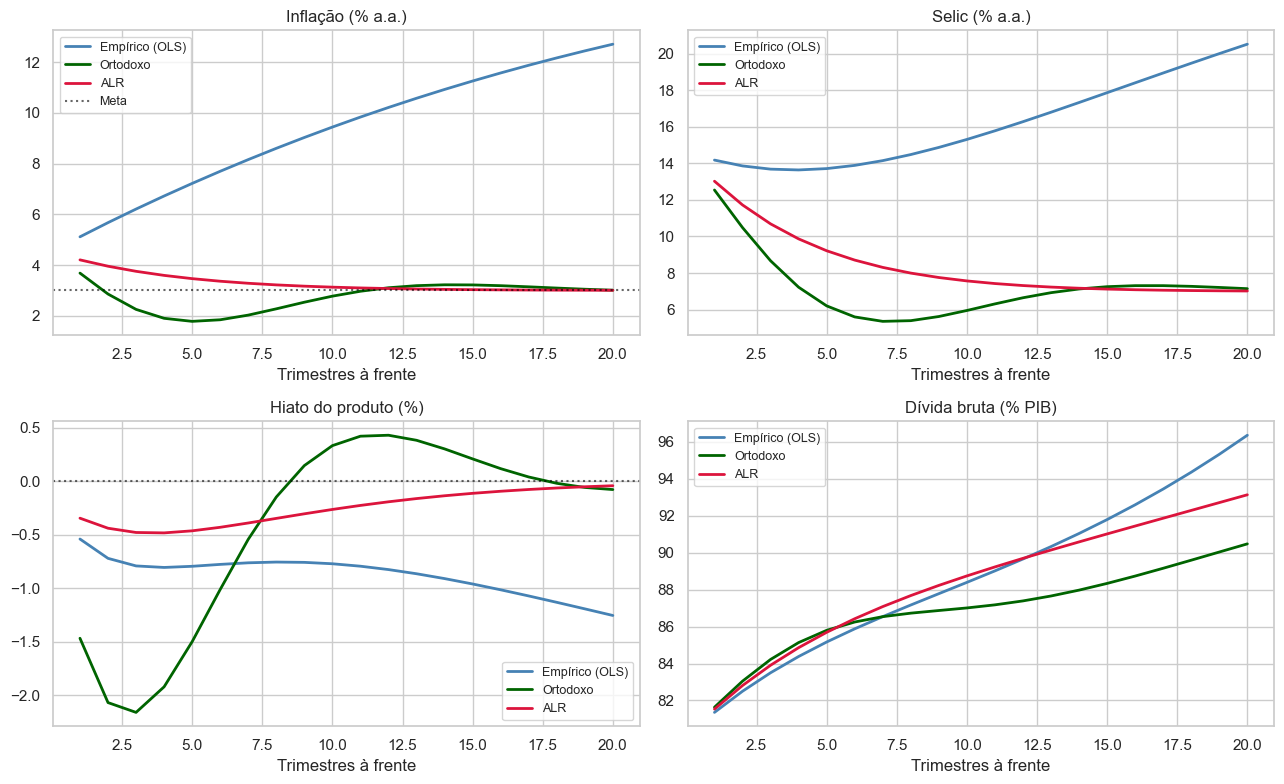

In [17]:
def _ultimo_valido(serie):
    """Pega o último valor não-NaN de uma série."""
    s = serie.dropna()
    return s.iloc[-1] if len(s) > 0 else np.nan


def simular(params: Parametros, H: int = 20,
            estado_inicial: dict = None,
            choques: dict = None, seed: int = 42) -> pd.DataFrame:
    """
    Simula o modelo por H trimestres.

    Convenções:
      - π, i, exp_pi, g_real estão em % ao ano
      - hiato em % do potencial
      - b em % do PIB
      - A dívida converte para trimestre via (1+x_anual)^(1/4) - 1
    """
    rng = np.random.default_rng(seed)
    estado_inicial = estado_inicial or {}

    # Pega ÚLTIMO VÁLIDO de cada série (não iloc[-1], que pode ser NaN
    # se o trimestre atual ainda não fechou)
    pi      = estado_inicial.get("pi",      _ultimo_valido(base["ipca_anual"]))
    i       = estado_inicial.get("i",       _ultimo_valido(base["selic"]))
    hiato   = estado_inicial.get("hiato",   _ultimo_valido(base["hiato"]))
    exp_pi  = estado_inicial.get("exp_pi",  _ultimo_valido(base["exp_ipca_12m"]))
    b       = estado_inicial.get("b",       _ultimo_valido(base["dbgg_pct_pib"]))
    if pd.isna(b):  # último fallback: usa params.b0 se ainda for NaN
        b = params.b0
    p_prim  = estado_inicial.get("p_prim",  _ultimo_valido(base["primario_12m"]))
    if pd.isna(p_prim):
        p_prim = -1.0
    g_real  = estado_inicial.get("g_real",  _ultimo_valido(base["g_real_yoy"]))
    if pd.isna(g_real):
        g_real = 2.0

    delta_e = 0.0

    # Validação: se algum input crítico é NaN, avisa
    if pd.isna(pi) or pd.isna(i) or pd.isna(hiato) or pd.isna(exp_pi):
        raise ValueError(
            f"Estado inicial contém NaN — pi={pi}, i={i}, "
            f"hiato={hiato}, exp_pi={exp_pi}. Verifique a base."
        )

    if choques is None:
        choques = {k: np.zeros(H) for k in ["pi", "y", "i", "e"]}

    trajetoria = []
    for t in range(H):
        # 1. Câmbio (AR1)
        delta_e = params.rho_e * delta_e + choques["e"][t]
        # 2. Hiato
        hiato_novo = is_curve(hiato, i, exp_pi, params, shock=choques["y"][t])
        # 3. Inflação (em % a.a.)
        pi_novo = phillips(pi, exp_pi, hiato_novo, delta_e, params,
                           shock=choques["pi"][t])
        # 4. Juros endógenos via Taylor (% a.a.)
        i_novo = taylor(i, pi_novo, hiato_novo, params, shock=choques["i"][t])
        # 5. Dívida — converte taxas anuais para trimestre
        i_q     = (1 + i/100)      ** 0.25 - 1
        pi_q    = (1 + pi_novo/100) ** 0.25 - 1
        g_q     = (1 + g_real/100)  ** 0.25 - 1
        p_q     = p_prim / 4
        b_novo = ((1 + i_q) / ((1 + pi_q) * (1 + g_q))) * b - p_q
        # 6. Expectativas adaptativas
        exp_pi_novo = 0.5 * pi_novo + 0.5 * params.pi_meta

        trajetoria.append({
            "t": t + 1, "pi": pi_novo, "i": i_novo,
            "hiato": hiato_novo, "b": b_novo,
            "delta_e": delta_e, "exp_pi": exp_pi_novo,
            "p_estab": primario_estabilizador(b_novo, i_novo, pi_novo, g_real),
            "p_prim": p_prim,
        })
        pi, i, hiato, b, exp_pi = pi_novo, i_novo, hiato_novo, b_novo, exp_pi_novo

    return pd.DataFrame(trajetoria)

# Roda os três cenários sem choques (apenas dinâmica determinística)
H = 20
resultados = {nome: simular(p, H=H) for nome, p in cenarios.items()}

# Plot comparativo
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
cores = {"Empírico (OLS)": "steelblue", "Ortodoxo": "darkgreen", "ALR": "crimson"}

for nome, df in resultados.items():
    axes[0,0].plot(df["t"], df["pi"], label=nome, color=cores[nome], linewidth=2)
    axes[0,1].plot(df["t"], df["i"],  label=nome, color=cores[nome], linewidth=2)
    axes[1,0].plot(df["t"], df["hiato"], label=nome, color=cores[nome], linewidth=2)
    axes[1,1].plot(df["t"], df["b"], label=nome, color=cores[nome], linewidth=2)

axes[0,0].axhline(PI_META, color="black", linestyle=":", alpha=0.6, label="Meta")
axes[0,0].set_title("Inflação (% a.a.)")
axes[0,1].set_title("Selic (% a.a.)")
axes[1,0].set_title("Hiato do produto (%)")
axes[1,0].axhline(0, color="black", linestyle=":", alpha=0.6)
axes[1,1].set_title("Dívida bruta (% PIB)")
for ax in axes.flat:
    ax.set_xlabel("Trimestres à frente")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### 6.1 Choque monetário — o experimento crucial

Aqui está o teste decisivo: **o que acontece se aumentarmos a Selic em 200 bps por choque exógeno?** Sob a calibração ortodoxa, a inflação cai. Sob a calibração ALR, quase nada acontece com a inflação — mas a dívida explode.

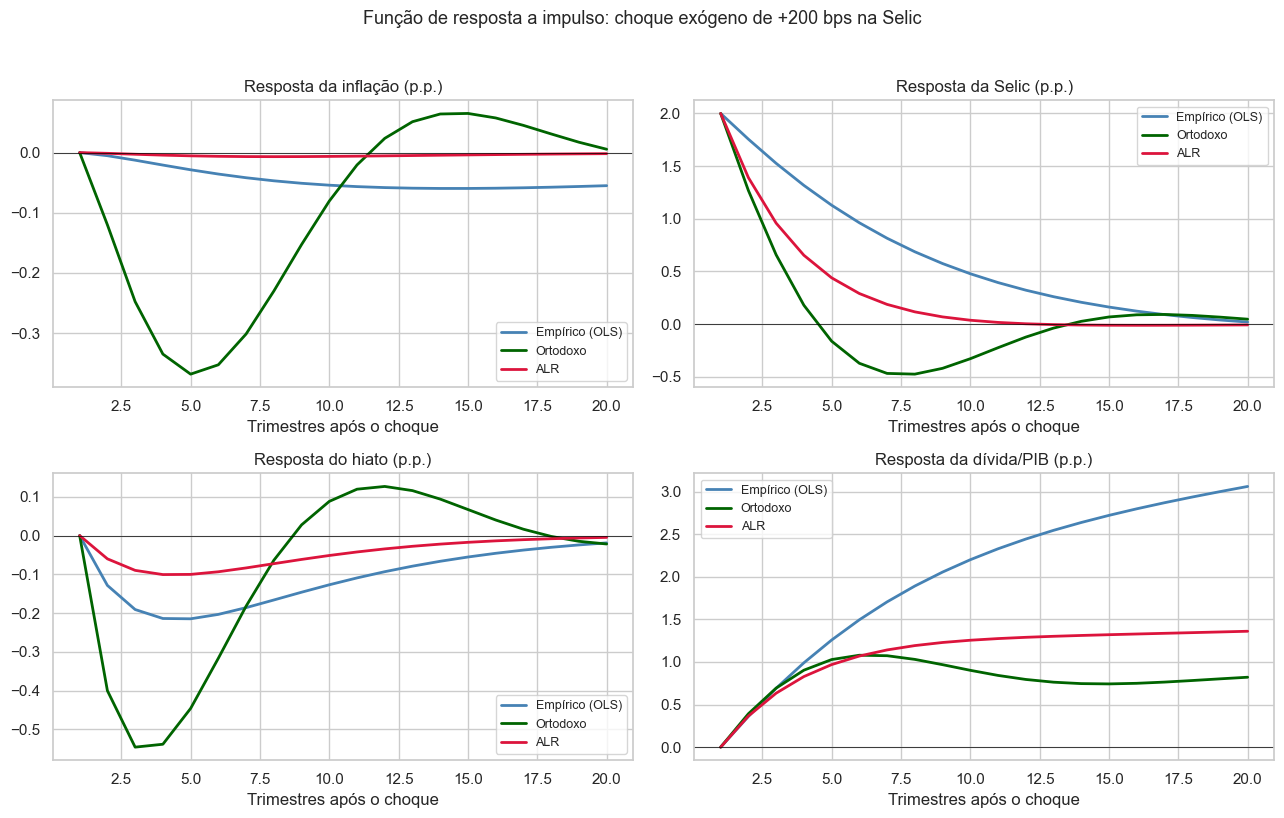


Desinflação acumulada em 8 trimestres (p.p. de IPCA):
  Empírico (OLS)      : -0.19
  Ortodoxo            : -1.95
  ALR                 : -0.03

Aumento da dívida em 8 trimestres (p.p. de PIB):
  Empírico (OLS)      : +1.89
  Ortodoxo            : +1.03
  ALR                 : +1.19


In [18]:
def choque_monetario(magnitude_pp=2.0, t_choque=1, H=20):
    """Aplica choque exógeno de +200bps na Selic no trimestre t_choque."""
    choques = {k: np.zeros(H) for k in ["pi", "y", "i", "e"]}
    choques["i"][t_choque - 1] = magnitude_pp
    return choques

choques = choque_monetario(magnitude_pp=2.0, t_choque=1, H=H)

# Roda baseline (sem choque) e com choque
baseline = {nome: simular(p, H=H) for nome, p in cenarios.items()}
com_choque = {nome: simular(p, H=H, choques=choques) for nome, p in cenarios.items()}

# IRF: diferença entre os dois
irf = {nome: com_choque[nome] - baseline[nome] for nome in cenarios}
for df in irf.values():
    df["t"] = baseline["Empírico (OLS)"]["t"]

fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for nome, df in irf.items():
    axes[0,0].plot(df["t"], df["pi"], label=nome, color=cores[nome], linewidth=2)
    axes[0,1].plot(df["t"], df["i"],  label=nome, color=cores[nome], linewidth=2)
    axes[1,0].plot(df["t"], df["hiato"], label=nome, color=cores[nome], linewidth=2)
    axes[1,1].plot(df["t"], df["b"], label=nome, color=cores[nome], linewidth=2)

for ax in axes.flat:
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_xlabel("Trimestres após o choque")
    ax.legend(fontsize=9)

axes[0,0].set_title("Resposta da inflação (p.p.)")
axes[0,1].set_title("Resposta da Selic (p.p.)")
axes[1,0].set_title("Resposta do hiato (p.p.)")
axes[1,1].set_title("Resposta da dívida/PIB (p.p.)")
plt.suptitle("Função de resposta a impulso: choque exógeno de +200 bps na Selic",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# Resumo numérico
print("\nDesinflação acumulada em 8 trimestres (p.p. de IPCA):")
for nome, df in irf.items():
    print(f"  {nome:<20}: {df['pi'].iloc[:8].sum():+.2f}")
print("\nAumento da dívida em 8 trimestres (p.p. de PIB):")
for nome, df in irf.items():
    print(f"  {nome:<20}: {df['b'].iloc[:8].iloc[-1]:+.2f}")

**Interpretação da IRF.** O quociente $\frac{\Delta b}{|\Delta \pi|}$ é o **custo fiscal da desinflação** — quantos pontos de dívida/PIB você acumula por cada ponto de inflação que você consegue derrubar. Esse é o número que o ALR quer destacar. Sob a calibração ALR esse quociente diverge (denominador ≈ 0); sob a ortodoxa, ele é finito e pequeno.

## 7. Aritmética da dívida pública acoplada

Aqui voltamos especificamente ao trecho do ALR. Calculamos o **superávit primário estabilizador** $p^* = [(1+i)/((1+\pi)(1+g)) − 1] \cdot b$ sob diferentes combinações de parâmetros.

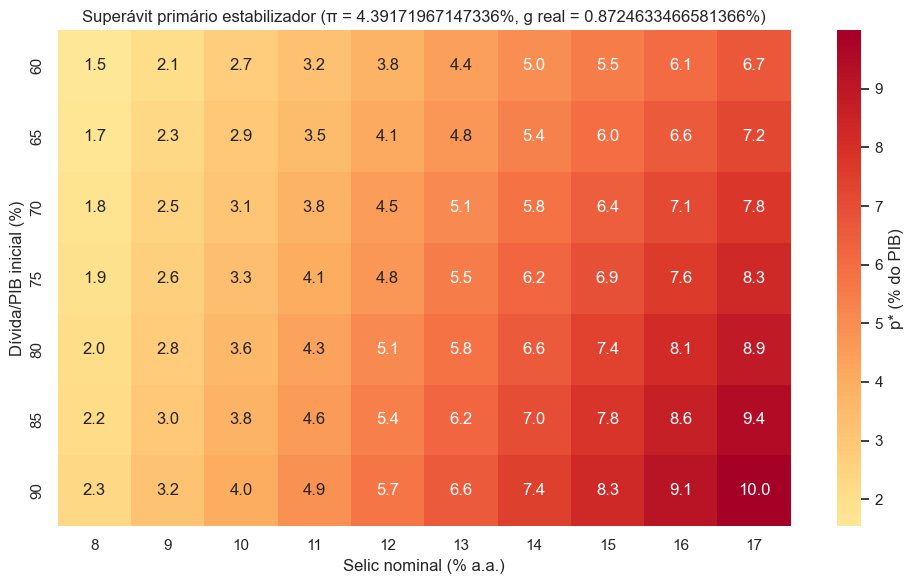


Valores atuais usados:
  π = 4.39% a.a.
  g = 0.87% a.a.
  b = 80.04% do PIB
  i = 14.65% a.a.

p* requerido nos valores correntes: 7.10% do PIB
p* observado (12m):                  1.06% do PIB


In [19]:
def heatmap_primario(b_grid=np.arange(60, 95, 5),
                     i_grid=np.arange(8, 18, 1),
                     pi=4.5, g=2.0):
    """Mapa de calor: p* em função de (b, i) para π e g fixos."""
    M = np.zeros((len(b_grid), len(i_grid)))
    for ib, b in enumerate(b_grid):
        for ii, i in enumerate(i_grid):
            M[ib, ii] = primario_estabilizador(b, i, pi, g)
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.heatmap(M, xticklabels=i_grid, yticklabels=b_grid, annot=True, fmt=".1f",
                cmap="RdYlGn_r", center=0,
                cbar_kws={"label": "p* (% do PIB)"}, ax=ax)
    ax.set_xlabel("Selic nominal (% a.a.)")
    ax.set_ylabel("Dívida/PIB inicial (%)")
    ax.set_title(f"Superávit primário estabilizador (π = {pi}%, g real = {g}%)")
    plt.tight_layout()
    plt.show()
    return pd.DataFrame(M, index=b_grid, columns=i_grid)

# Estado atual aproximado
mat_atual = heatmap_primario(pi=base["ipca_anual"].dropna().iloc[-1],
                              g=base["g_real_yoy"].dropna().iloc[-1])
print(f"\nValores atuais usados:")
print(f"  π = {base["ipca_anual"].dropna().iloc[-1]:.2f}% a.a.")
print(f"  g = {base["g_real_yoy"].dropna().iloc[-1]:.2f}% a.a.")
print(f"  b = {base["dbgg_pct_pib"].dropna().iloc[-1]:.2f}% do PIB")
print(f"  i = {base["selic"].dropna().iloc[-1]:.2f}% a.a.")
print(f"\np* requerido nos valores correntes: "
      f"{primario_estabilizador(base["dbgg_pct_pib"].dropna().iloc[-1], base["selic"].dropna().iloc[-1], base["ipca_anual"].dropna().iloc[-1], base["g_real_yoy"].dropna().iloc[-1]):.2f}% do PIB")
print(f"p* observado (12m):                  "
      f"{base["primario_12m"].dropna().iloc[-1]:.2f}% do PIB")

### 7.1 Decomposição: quem está pagando a conta?

A diferença entre o **superávit estabilizador** e o **superávit observado** mostra o gap fiscal — quanto o governo precisaria cortar gasto ou aumentar tributação para parar de aumentar a dívida.

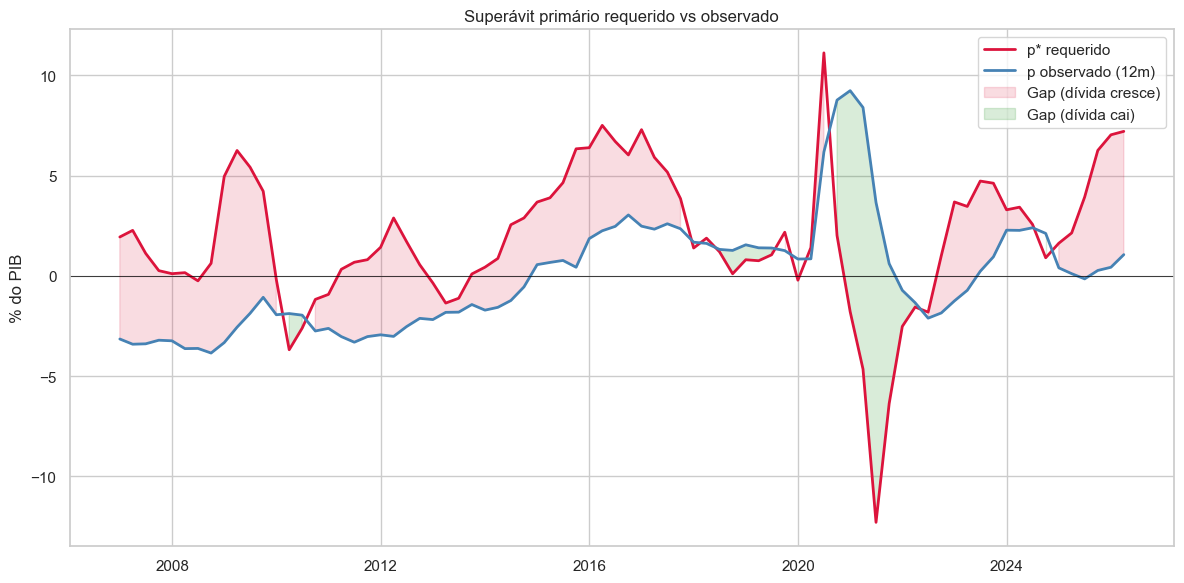


Últimas 8 observações:
            selic  ipca_anual  g_real_yoy  primario_12m  p_estabilizador  \
data                                                                       
2024-06-30  10.60        4.23        2.68          2.40             2.57   
2024-09-30  10.53        4.42        4.62          2.12             0.90   
2024-12-31  11.27        4.83        3.92          0.40             1.63   
2025-03-31  13.06        5.48        4.24          0.11             2.14   
2025-06-30  14.58        5.35        3.43         -0.15             3.93   
2025-09-30  15.00        5.17        1.21          0.27             6.26   
2025-12-31  15.00        4.26        1.24          0.43             7.04   
2026-03-31  14.96        4.14        1.27          1.06             7.21   

            gap_fiscal  
data                    
2024-06-30        0.17  
2024-09-30       -1.22  
2024-12-31        1.23  
2025-03-31        2.03  
2025-06-30        4.08  
2025-09-30        5.99  
2025-12-31     

In [20]:
# Série histórica do gap fiscal
historico = base[["dbgg_pct_pib", "selic", "ipca_anual", "g_real_yoy", "primario_12m"]].dropna()
historico["p_estabilizador"] = historico.apply(
    lambda r: primario_estabilizador(r["dbgg_pct_pib"], r["selic"],
                                      r["ipca_anual"], r["g_real_yoy"]),
    axis=1
)
historico["gap_fiscal"] = historico["p_estabilizador"] - historico["primario_12m"]

fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(historico.index, historico["p_estabilizador"], label="p* requerido", 
        color="crimson", linewidth=2)
ax.plot(historico.index, historico["primario_12m"],   label="p observado (12m)",
        color="steelblue", linewidth=2)
ax.fill_between(historico.index, historico["p_estabilizador"], historico["primario_12m"],
                where=historico["p_estabilizador"] > historico["primario_12m"],
                color="crimson", alpha=0.15, label="Gap (dívida cresce)")
ax.fill_between(historico.index, historico["p_estabilizador"], historico["primario_12m"],
                where=historico["p_estabilizador"] <= historico["primario_12m"],
                color="green", alpha=0.15, label="Gap (dívida cai)")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_title("Superávit primário requerido vs observado")
ax.set_ylabel("% do PIB")
ax.legend()
plt.tight_layout()
plt.show()

print("\nÚltimas 8 observações:")
print(historico[["selic", "ipca_anual", "g_real_yoy", "primario_12m",
                 "p_estabilizador", "gap_fiscal"]].tail(8).round(2))

### 7.2 Quebra estrutural na curva de Phillips

Uma das hipóteses do ALR é que a sensibilidade da inflação aos juros **caiu ao longo do tempo** — economia mudou, transmissão monetária enfraqueceu. Testamos isso dividindo a amostra em pré-2015 (regime de meta clássico, Tombini) e pós-2015 (pós-crise política, Tombini→Goldfajn→Campos Neto→Galípolo). Comparamos $\kappa$ entre os dois períodos.

Comparação dos parâmetros da Phillips por subperíodo:

                   obs       κ     p_κ     β_b     β_f       γ      R²
Amostra completa  92.0  0.0401  0.4058  0.7028  0.5196 -0.0001  0.8223
Pré-2015          47.0  0.0504  0.3916  0.6781  0.5681 -0.0205  0.8723
Pós-2015          45.0  0.0642  0.2879  0.6649  0.7973  0.0101  0.7976


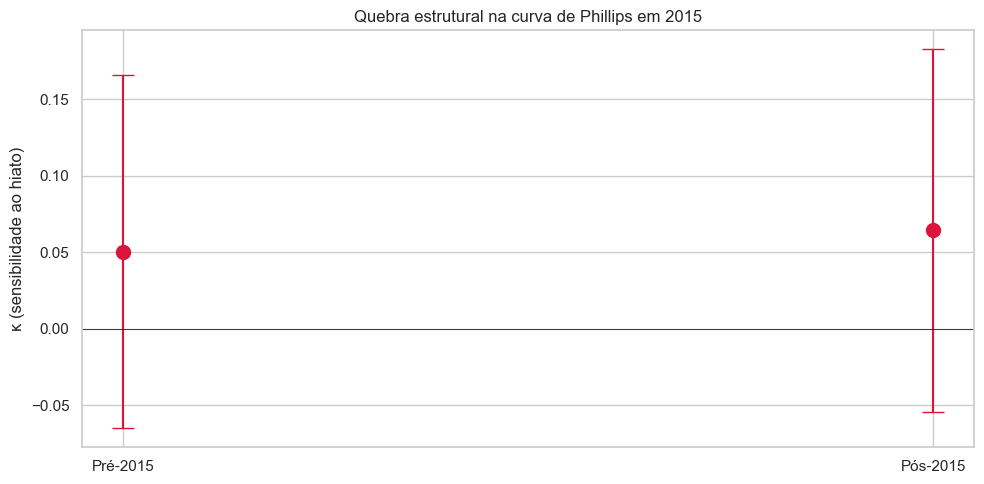


Variação de κ: 0.050 → 0.064 (sobe 0.014 p.p.)


In [21]:
# Quebra estrutural na Phillips
DATA_QUEBRA = "2015-01-01"

df_phillips_full = base[["ipca_anual", "exp_ipca_12m", "hiato", "delta_cambio"]].dropna().copy()
df_phillips_full["ipca_lag"] = df_phillips_full["ipca_anual"].shift(1)
df_phillips_full = df_phillips_full.dropna()

resultados_quebra = {}
for nome, df_sub in [("Amostra completa", df_phillips_full),
                     (f"Pré-{DATA_QUEBRA[:4]}", df_phillips_full[df_phillips_full.index < DATA_QUEBRA]),
                     (f"Pós-{DATA_QUEBRA[:4]}", df_phillips_full[df_phillips_full.index >= DATA_QUEBRA])]:
    if len(df_sub) < 10:
        continue
    X = sm.add_constant(df_sub[["ipca_lag", "exp_ipca_12m", "hiato", "delta_cambio"]])
    y = df_sub["ipca_anual"]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    resultados_quebra[nome] = {
        "obs": len(df_sub),
        "κ": m.params["hiato"],
        "p_κ": m.pvalues["hiato"],
        "β_b": m.params["ipca_lag"],
        "β_f": m.params["exp_ipca_12m"],
        "γ":   m.params["delta_cambio"],
        "R²":  m.rsquared,
    }

df_quebra = pd.DataFrame(resultados_quebra).T
print("Comparação dos parâmetros da Phillips por subperíodo:\n")
print(df_quebra.round(4))

# Plot comparativo
fig, ax = plt.subplots(figsize=(10, 5))
periodos = list(resultados_quebra.keys())
kappas = [resultados_quebra[p]["κ"] for p in periodos]
intervalos = []
for p, df_sub in [(f"Pré-{DATA_QUEBRA[:4]}", df_phillips_full[df_phillips_full.index < DATA_QUEBRA]),
                  (f"Pós-{DATA_QUEBRA[:4]}", df_phillips_full[df_phillips_full.index >= DATA_QUEBRA])]:
    if len(df_sub) < 10:
        continue
    X = sm.add_constant(df_sub[["ipca_lag", "exp_ipca_12m", "hiato", "delta_cambio"]])
    y = df_sub["ipca_anual"]
    m = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": 4})
    ci = m.conf_int().loc["hiato"]
    intervalos.append((p, m.params["hiato"], ci[0], ci[1]))

if intervalos:
    nomes = [x[0] for x in intervalos]
    coef  = [x[1] for x in intervalos]
    lo    = [x[1] - x[2] for x in intervalos]
    hi    = [x[3] - x[1] for x in intervalos]
    ax.errorbar(nomes, coef, yerr=[lo, hi], fmt="o", capsize=8, color="crimson", markersize=10)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_ylabel("κ (sensibilidade ao hiato)")
    ax.set_title(f"Quebra estrutural na curva de Phillips em {DATA_QUEBRA[:4]}")
    plt.tight_layout()
    plt.show()

print(f"\nVariação de κ: {kappas[1]:.3f} → {kappas[2]:.3f} "
      f"({'cai' if kappas[2] < kappas[1] else 'sobe'} {abs(kappas[2]-kappas[1]):.3f} p.p.)")

### 7.3 Decomposição do custo fiscal

Aqui calculamos, sob o cenário empírico (com os $\kappa$ e $\sigma$ estimados), **quantos pontos de dívida/PIB** o Brasil acumulou nos últimos 12 trimestres por causa de:

1. **Juro real elevado** (canal $r \cdot b$)  
2. **Crescimento abaixo do potencial** ($-g \cdot b$)  
3. **Déficit primário** ($-p$)

Esta decomposição mostra qual peça da equação $\Delta b = (r-g) \cdot b - p$ está dominando.

Variação total da DBGG nos últimos 12 trimestres: +8.50 p.p. do PIB

Decomposição contábil (% do PIB acumulado):
  Juros reais        : +19.03
  Crescimento (−g·b) :  -6.15
  Resultado primário :  -3.09
  Resíduo            :  -1.29
  Soma              :  +8.50


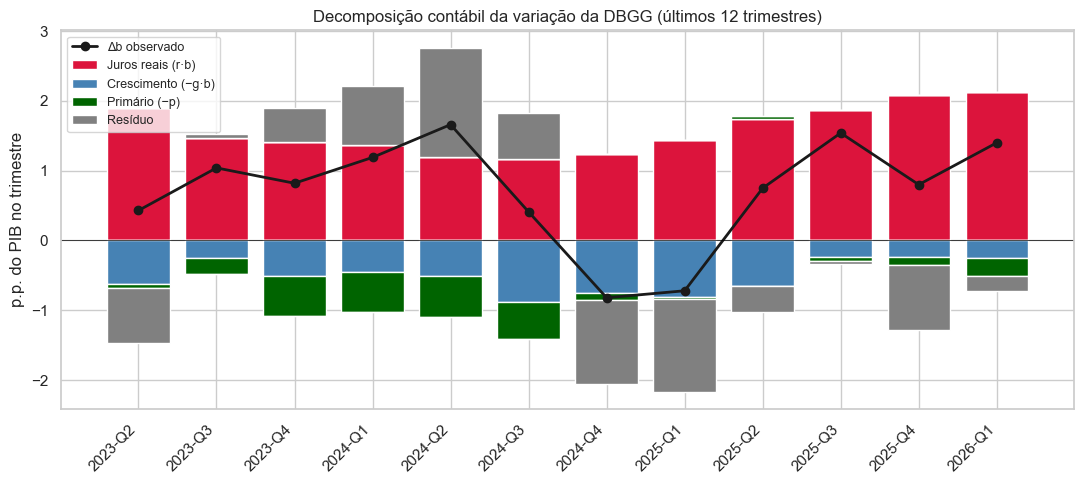

In [22]:
# Decomposição contábil do crescimento da dívida nos últimos 12 trimestres
# Δb_t ≈ (r_t - g_t) · b_{t-1} - p_t
hist = base[["dbgg_pct_pib", "selic", "ipca_anual", "g_real_yoy", "primario_12m"]].dropna()

hist["b_lag"]      = hist["dbgg_pct_pib"].shift(1)
hist["juro_real"]  = hist["selic"] - hist["ipca_anual"]  # aproximação ex-post
hist["delta_b"]    = hist["dbgg_pct_pib"] - hist["b_lag"]

# Contribuições (já anualizadas, dividimos por 4 para trimestre)
hist["contrib_juro"]    = (hist["juro_real"] / 100) * hist["b_lag"] / 4
hist["contrib_g"]       = -(hist["g_real_yoy"] / 100) * hist["b_lag"] / 4
hist["contrib_primario"] = -hist["primario_12m"] / 4
hist["contrib_residual"] = hist["delta_b"] - (hist["contrib_juro"]
                                              + hist["contrib_g"]
                                              + hist["contrib_primario"])

# Últimos 12 trimestres
ultimo_periodo = hist.tail(12)
total = ultimo_periodo[["contrib_juro", "contrib_g",
                        "contrib_primario", "contrib_residual"]].sum()
delta_total = ultimo_periodo["delta_b"].sum()

print(f"Variação total da DBGG nos últimos 12 trimestres: {delta_total:+.2f} p.p. do PIB\n")
print("Decomposição contábil (% do PIB acumulado):")
print(f"  Juros reais        : {total['contrib_juro']:+6.2f}")
print(f"  Crescimento (−g·b) : {total['contrib_g']:+6.2f}")
print(f"  Resultado primário : {total['contrib_primario']:+6.2f}")
print(f"  Resíduo            : {total['contrib_residual']:+6.2f}")
print(f"  Soma              : {total.sum():+6.2f}")

# Plot de barras empilhadas
fig, ax = plt.subplots(figsize=(11, 5))
cores = {"contrib_juro": "crimson", "contrib_g": "steelblue",
         "contrib_primario": "darkgreen", "contrib_residual": "gray"}
labels = {"contrib_juro": "Juros reais (r·b)",
          "contrib_g": "Crescimento (−g·b)",
          "contrib_primario": "Primário (−p)",
          "contrib_residual": "Resíduo"}

bottom_pos = np.zeros(len(ultimo_periodo))
bottom_neg = np.zeros(len(ultimo_periodo))
x = np.arange(len(ultimo_periodo))
for col in ["contrib_juro", "contrib_g", "contrib_primario", "contrib_residual"]:
    vals = ultimo_periodo[col].values
    pos = np.where(vals > 0, vals, 0)
    neg = np.where(vals < 0, vals, 0)
    ax.bar(x, pos, bottom=bottom_pos, color=cores[col], label=labels[col], width=0.8)
    ax.bar(x, neg, bottom=bottom_neg, color=cores[col], width=0.8)
    bottom_pos += pos
    bottom_neg += neg

# Linha de variação total observada
ax.plot(x, ultimo_periodo["delta_b"].values, "o-k", linewidth=2,
        markersize=6, label="Δb observado")
ax.axhline(0, color="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels([f"{d.year}-Q{(d.month-1)//3+1}"
                    for d in ultimo_periodo.index], rotation=45, ha="right")
ax.set_ylabel("p.p. do PIB no trimestre")
ax.set_title("Decomposição contábil da variação da DBGG (últimos 12 trimestres)")
ax.legend(loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

### 7.4 Tabela síntese para o capítulo

Consolidação dos resultados-chave em uma única tabela, pronta para incluir como Tabela 1 no capítulo. Ela cruza os três cenários (Empírico, Ortodoxo, ALR) com as variáveis de interesse (parâmetros estimados, IRF, custo fiscal).

In [23]:
# Recalcula IRF para cada cenário (em caso de não ter rodado antes)
H = 20
choques_irf = {k: np.zeros(H) for k in ["pi", "y", "i", "e"]}
choques_irf["i"][0] = 2.0  # +200 bps

tabela = []
for nome, params in cenarios.items():
    baseline_irf  = simular(params, H=H)
    com_choque_irf = simular(params, H=H, choques=choques_irf)
    irf = com_choque_irf - baseline_irf
    
    desinf_8t  = irf["pi"].iloc[:8].sum()
    deltadiv_8t = irf["b"].iloc[7]
    custo_fiscal = abs(deltadiv_8t / desinf_8t) if abs(desinf_8t) > 0.01 else float("inf")
    
    tabela.append({
        "Cenário": nome,
        "κ": params.kappa,
        "σ": params.sigma,
        "β_b": params.beta_b,
        "β_f": params.beta_f,
        "φ_π": params.phi_pi,
        "Δπ (8t, p.p.)":  round(desinf_8t, 2),
        "Δb (8t, p.p.)":  round(deltadiv_8t, 2),
        "Custo fiscal":    round(custo_fiscal, 1) if custo_fiscal != float("inf") else "∞",
    })

df_tabela = pd.DataFrame(tabela).set_index("Cenário")
print("TABELA 1 — Síntese dos cenários e do custo fiscal da desinflação")
print("="*78)
print(df_tabela.to_string())
print("="*78)
print()
print("Onde:")
print("  κ, σ: parâmetros da Phillips e da IS")
print("  Δπ (8t): desinflação acumulada em 8 trimestres após choque +200bps na Selic")
print("  Δb (8t): variação da dívida/PIB no 8º trimestre após mesmo choque")
print("  Custo fiscal: |Δb / Δπ| — p.p. de dívida por p.p. de inflação derrubada")

# Exporta como CSV para uso no capítulo
df_tabela.to_csv(CACHE_DIR / "tabela_sintese_cenarios.csv")
print(f"\nTabela salva em {CACHE_DIR / 'tabela_sintese_cenarios.csv'}")

TABELA 1 — Síntese dos cenários e do custo fiscal da desinflação
                       κ         σ       β_b       β_f       φ_π  Δπ (8t, p.p.)  Δb (8t, p.p.)  Custo fiscal
Cenário                                                                                                     
Empírico (OLS)  0.040107  0.064259  0.702806  0.519637  2.012688          -0.19           1.89           9.9
Ortodoxo        0.300000  0.200000  0.400000  0.600000  2.000000          -1.95           1.03           0.5
ALR             0.020000  0.030000  0.600000  0.400000  2.000000          -0.03           1.19          36.1

Onde:
  κ, σ: parâmetros da Phillips e da IS
  Δπ (8t): desinflação acumulada em 8 trimestres após choque +200bps na Selic
  Δb (8t): variação da dívida/PIB no 8º trimestre após mesmo choque
  Custo fiscal: |Δb / Δπ| — p.p. de dívida por p.p. de inflação derrubada

Tabela salva em cache_dados\tabela_sintese_cenarios.csv


## 8. Síntese e extensões propostas

**O que este notebook permite responder quantitativamente:**

1. *Qual o valor empírico de $\kappa$ na curva de Phillips brasileira?* — Seção 3.1, OLS na base trimestral 2002-presente.
2. *Quanto custa em dívida/PIB cada ponto de inflação que a Selic derruba?* — Seção 6.1, função de resposta a impulso.
3. *Qual o superávit primário necessário hoje, ontem, e na data X?* — Seção 7, decomposição histórica.
4. *Se ALR estiver certo (κ ≈ 0), quanto Selic mais alta custa fiscalmente sem benefício inflacionário?* — Compare baseline ALR com choque monetário na Seção 6.1.

**Extensões que valem a pena fazer:**

- **Composição da dívida (LFT vs prefixados)**: a fração de LFT torna a transmissão da Selic ao serviço da dívida quase contemporânea (lag ~0). Refinar a equação da dívida para refletir isso muda quantitativamente o custo fiscal — incorporar com dados do Tesouro Transparente.
- **Pass-through cambial completo**: separar o canal $\Delta e \to \pi$ por componente (livres, monitorados) e estimar com IPCA desagregado já baixado em `CATALOGO_SGS`.
- **Quebras estruturais**: rodar Chow ou Bai-Perron na curva de Phillips para checar se κ caiu após 2015 (hipótese empírica do próprio ALR).
- **GMM em vez de OLS**: a expectativa Focus está correlacionada com o erro da Phillips. Instrumentar com defasagens.
- **Regra de Taylor não-linear**: usar threshold model para checar se o BCB responde diferente quando $\pi > \pi^* + 2$ vs próximo à meta.
- **Cenário fiscal forward-looking**: tornar $p_t$ endógeno via regra "fiscal reaction function" estilo Bohn (1998).

**Sobre os limites do exercício.** Este é um modelo reduced-form, calibrado por OLS equação-a-equação, sem expectativas racionais consistentes. Para análise de política mais robusta, o próximo passo natural é um modelo semi-estrutural tipo SAMBA do BCB ou um DSGE pequeno (3 equações em forma estrutural com $\mathbb{E}_t$ resolvidos por método de Sims/Klein). Mas para entender quantitativamente o argumento ALR — e ver onde a aritmética dele acerta e onde simplifica — o nível reduced-form é suficiente.
